In [1]:
import os
import glob
import pandas as pd
import numpy as np
import datetime as datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import math

In [3]:
from scipy.signal import butter, filtfilt

In [4]:
import kneed
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [5]:
col_name_cur = ['Ext', 'EID', 'PID', 'Datetime', 'DOW', 'Status', '00']
col_num = [f'{i}' for i in range(69)]

col_names = col_name_cur + col_num

In [6]:
file_names = ['../sound_proj_2/data/Raw-data/Yokota/data_txt/2022-10-01.txt',
              '../sound_proj_2/data/Raw-data/Yokota/data_txt/2022-10-02.txt',
              '../sound_proj_2/data/Raw-data/Yokota/data_txt/2022-10-03.txt',
              '../sound_proj_2/data/Raw-data/Yokota/data_txt/2022-10-04.txt',
              '../sound_proj_2/data/Raw-data/Yokota/data_txt/2022-10-05.txt',]

In [7]:
df_list = []

for f in file_names:
    df = pd.read_csv(f, names=col_names, sep='\t')
    df_clean = df.dropna(axis=1)
    df_tran = df_clean.drop(['Ext', 'EID', 'PID', 'DOW', 'Status', '00', '60'], axis=1)
    df_tran['Datetime'] = pd.to_datetime(df_tran['Datetime'], format='%Y/%m/%d    %H:%M:%S')

    for i in range(len(df_tran)-1):
        start = df_tran.loc[i]['Datetime']
        end = df_tran.loc[i+1]['Datetime']
        diff = end - start

        if(diff != datetime.timedelta(minutes=1)):
            diff_num = int((diff / np.timedelta64(1, 'm'))) - 1
            df2 = pd.DataFrame([[start + datetime.timedelta(minutes=m+1)] for m in range(diff_num)], columns=['Datetime'])
            df_tran = pd.concat([df_tran, df2]).reset_index(drop=True)
            
    df_list.append(df_tran)

In [8]:
df_data_list = []

for i in range(len(df_list)):
    data_list = []

    for j in range(len(df_list[i])-1):
        dt = [df_list[i].loc[j]['Datetime'] + datetime.timedelta(seconds=s) for s in range(60)]
        data = np.array(df_list[i].iloc[j]["0":"59"])

        data_dict = {"Period start":dt, "Leq":data}
        df_data = pd.DataFrame(data_dict)
        data_list.append(df_data)
    
    df_merge = pd.concat(data_list).reset_index(drop=True)

    df_merge_copy = df_merge.copy()
    df_merge_copy['Leq'] = df_merge_copy['Leq'].fillna(df_merge['Leq'].mean())
    df_merge_copy['Leq'] = df_merge_copy['Leq'].replace(0.0, df_merge['Leq'].mean())
    
    df_merge_copy = df_merge_copy.sort_values(by=['Period start'])
    df_data_list.append(df_merge_copy)

In [9]:
df_data = pd.concat(df_data_list).reset_index(drop=True)
df_data

,Period start,Leq
0,2023-10-01 00:00:00,57.1
1,2023-10-01 00:00:01,56.6
2,2023-10-01 00:00:02,59.0
3,2023-10-01 00:00:03,58.1
4,2023-10-01 00:00:04,57.4
...,...,...
431695,2023-10-05 23:59:55,66.7
431696,2023-10-05 23:59:56,64.6
431697,2023-10-05 23:59:57,61.8
431698,2023-10-05 23:59:58,60.7


In [10]:
n_data_points = len(df_data)
print(n_data_points)

431700


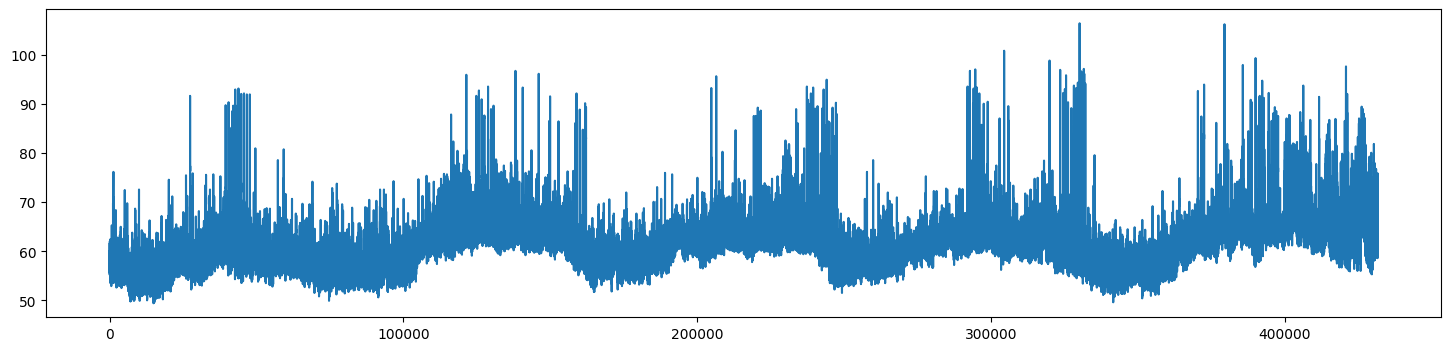

In [11]:
plt.figure(figsize=(18,4))
plt.plot(df_data['Leq'])
plt.show()

In [12]:
one_hr = 3600

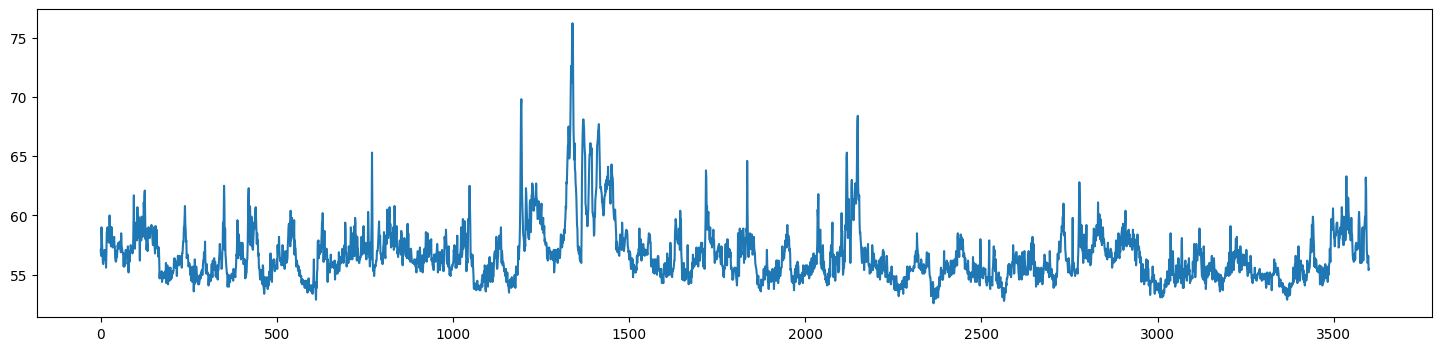

In [15]:
plt.figure(figsize=(18,4))
plt.plot(df_data['Leq'][:one_hr+1])
plt.show()

In [16]:
def cutoff(r, data):
    r = (100 - r) / 1000
    b, a = butter(4, r)
    filtered = filtfilt(b, a, data)
    return filtered

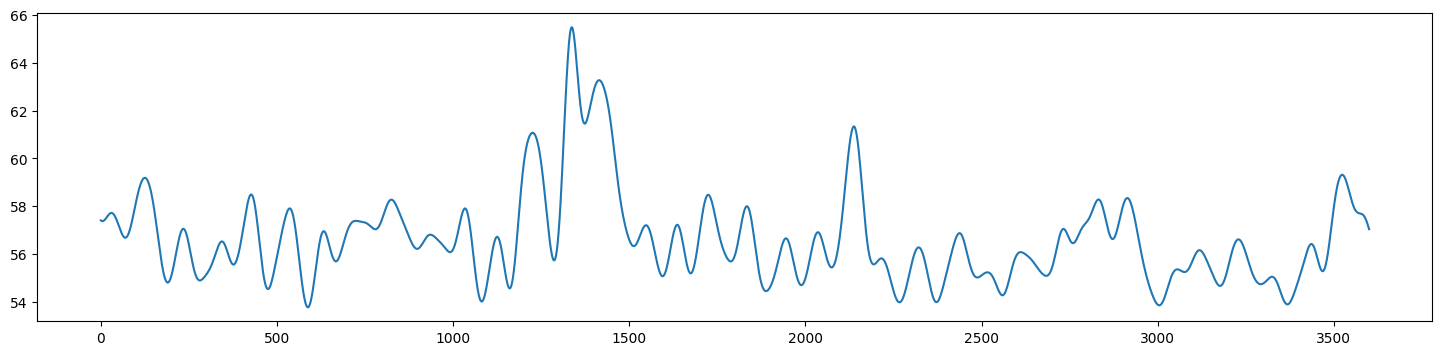

In [37]:
rate = 70
if(rate < 100):
    sound_cutoff = cutoff(rate, df_data['Leq'])
    plt.figure(figsize=(18,4))
    plt.plot(sound_cutoff[:one_hr+1])
    plt.show()
else:
    print("Error")

In [38]:
df_data = df_data.assign(Leq_filtered=sound_cutoff)

In [39]:
df_data

,Period start,Leq,Leq_filtered
0,2023-10-01 00:00:00,57.1,57.410173
1,2023-10-01 00:00:01,56.6,57.398393
2,2023-10-01 00:00:02,59.0,57.389630
3,2023-10-01 00:00:03,58.1,57.383868
4,2023-10-01 00:00:04,57.4,57.381063
...,...,...,...
431695,2023-10-05 23:59:55,66.7,69.179466
431696,2023-10-05 23:59:56,64.6,69.156675
431697,2023-10-05 23:59:57,61.8,69.136464
431698,2023-10-05 23:59:58,60.7,69.118827


In [40]:
df_copy = df_data.copy()

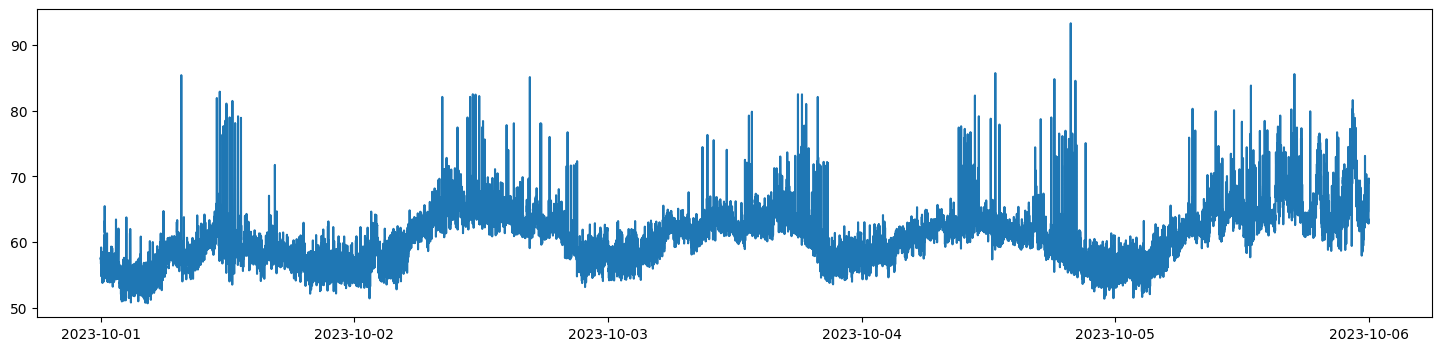

In [41]:
plt.figure(figsize=(18,4))
plt.plot(df_copy['Period start'], df_copy['Leq_filtered'])
plt.show()

In [42]:
test2 = np.array(df_copy['Leq_filtered'])
test2 = test2.reshape(-1,1)

In [43]:
scaler = StandardScaler()
test2_normalized = scaler.fit_transform(test2)

In [44]:
df_copy['Leq_norm'] = test2_normalized
df_copy

,Period start,Leq,Leq_filtered,Leq_norm
0,2023-10-01 00:00:00,57.1,57.410173,-0.826195
1,2023-10-01 00:00:01,56.6,57.398393,-0.828957
2,2023-10-01 00:00:02,59.0,57.389630,-0.831012
3,2023-10-01 00:00:03,58.1,57.383868,-0.832363
4,2023-10-01 00:00:04,57.4,57.381063,-0.833020
...,...,...,...,...
431695,2023-10-05 23:59:55,66.7,69.179466,1.933319
431696,2023-10-05 23:59:56,64.6,69.156675,1.927976
431697,2023-10-05 23:59:57,61.8,69.136464,1.923237
431698,2023-10-05 23:59:58,60.7,69.118827,1.919102


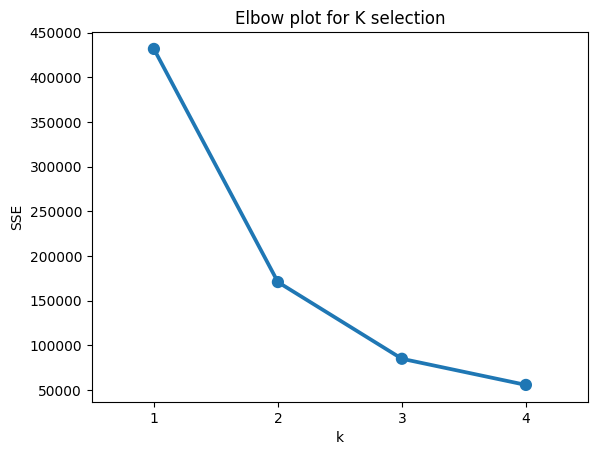

In [45]:
sse = {}

for k in range(1, 5):
  kmeans = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)
  sse[k] = kmeans.inertia_

plt.title('Elbow plot for K selection')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [46]:
kn = kneed.KneeLocator(
    x=list(sse.keys()), 
    y=list(sse.values()), 
    curve='convex', 
    direction='decreasing', S=0.0)

In [47]:
k = kn.knee
kmeans_best = KMeans(n_clusters=k, random_state=0).fit(test2_normalized)

In [48]:
df_copy['cluster'] = kmeans_best.labels_
df_copy

,Period start,Leq,Leq_filtered,Leq_norm,cluster
0,2023-10-01 00:00:00,57.1,57.410173,-0.826195,1
1,2023-10-01 00:00:01,56.6,57.398393,-0.828957,1
2,2023-10-01 00:00:02,59.0,57.389630,-0.831012,1
3,2023-10-01 00:00:03,58.1,57.383868,-0.832363,1
4,2023-10-01 00:00:04,57.4,57.381063,-0.833020,1
...,...,...,...,...,...
431695,2023-10-05 23:59:55,66.7,69.179466,1.933319,0
431696,2023-10-05 23:59:56,64.6,69.156675,1.927976,0
431697,2023-10-05 23:59:57,61.8,69.136464,1.923237,0
431698,2023-10-05 23:59:58,60.7,69.118827,1.919102,0


In [49]:
clusters = np.unique(kmeans_best.labels_)

In [50]:
avg_cluster = [df_copy[df_copy['cluster'] == i]['Leq_filtered'].mean() for i in range(kn.knee)]
avg_cluster

[64.31783807894548, 57.68697090060037]

In [51]:
max_cluster = np.array(avg_cluster).argmax()
max_cluster

0

In [52]:
peak_count = len(df_copy[df_copy['cluster'] == max_cluster])
unix_time = np.array(df_copy['Period start'])
time_on_max_clusters = np.array(df_copy[df_copy['cluster'] == max_cluster].index)
print("Peak count: %d" % peak_count)

Peak count: 211389


In [53]:
X = time_on_max_clusters.reshape(-1,1)

In [54]:
df_dbscan = df_copy.copy()

In [55]:
dbscan = DBSCAN(eps=150, min_samples=10).fit(X)

In [57]:
df_dbscan = df_dbscan.iloc[time_on_max_clusters]
df_dbscan['peak group'] = dbscan.labels_

In [58]:
df_dbscan = df_dbscan[df_dbscan['peak group'] != -1]
df_dbscan

,Period start,Leq,Leq_filtered,Leq_norm,cluster,peak group
1219,2023-10-01 00:20:19,61.3,60.992760,0.013804,0,0
1220,2023-10-01 00:20:20,60.5,61.014816,0.018976,0,0
1221,2023-10-01 00:20:21,58.6,61.033285,0.023306,0,0
1222,2023-10-01 00:20:22,60.4,61.048198,0.026803,0,0
1223,2023-10-01 00:20:23,61.7,61.059561,0.029467,0,0
...,...,...,...,...,...,...
431695,2023-10-05 23:59:55,66.7,69.179466,1.933319,0,190
431696,2023-10-05 23:59:56,64.6,69.156675,1.927976,0,190
431697,2023-10-05 23:59:57,61.8,69.136464,1.923237,0,190
431698,2023-10-05 23:59:58,60.7,69.118827,1.919102,0,190


In [60]:
n = len(np.unique(dbscan.labels_))
dbscan_labels = df_dbscan['peak group'].unique()

In [61]:
df2 = df_dbscan['peak group']

In [62]:
df_merge = pd.concat([df_copy, df2], axis=1)
df_merge['peak group'] = df_merge['peak group'].fillna(-1)
df_merge

,Period start,Leq,Leq_filtered,Leq_norm,cluster,peak group
0,2023-10-01 00:00:00,57.1,57.410173,-0.826195,1,-1.0
1,2023-10-01 00:00:01,56.6,57.398393,-0.828957,1,-1.0
2,2023-10-01 00:00:02,59.0,57.389630,-0.831012,1,-1.0
3,2023-10-01 00:00:03,58.1,57.383868,-0.832363,1,-1.0
4,2023-10-01 00:00:04,57.4,57.381063,-0.833020,1,-1.0
...,...,...,...,...,...,...
431695,2023-10-05 23:59:55,66.7,69.179466,1.933319,0,190.0
431696,2023-10-05 23:59:56,64.6,69.156675,1.927976,0,190.0
431697,2023-10-05 23:59:57,61.8,69.136464,1.923237,0,190.0
431698,2023-10-05 23:59:58,60.7,69.118827,1.919102,0,190.0


In [63]:
print("Clustered peak count: %d" % len(set(dbscan_labels)))

Clustered peak count: 191


In [65]:
def computeL_eq_t(data):
    sum_pow = np.sum(np.power(10, data/10))
    x = 1/len(data) * sum_pow 
    return 10 * math.log(x,10)

def SoundAddition(data):
    x = np.sum(np.power(10, data/10))
    return 10 * math.log(x,10)

def computeSEL(data):
    return computeL_eq_t(data) + 10 * math.log((len(data)*100)/1000)

In [82]:
results = []
hours = [[] for i in range(int(math.ceil(n_data_points//3600)))]

In [83]:
data_dict = [{c:np.nan} for c in dbscan_labels]
peak_median = [np.median(df_dbscan[df_dbscan['peak group'] == i].index) for i in range(n) if (len(df_dbscan[df_dbscan['peak group'] == i]) != 0)]

In [84]:
for c in dbscan_labels:
    c_data = df_merge[df_merge['peak group'] == c].index
    min_t, max_t = c_data.min(), c_data.max()
    peak_t = int(peak_median[c])

    in_which_hour = min_t//3600

    raw = np.array(df_merge[df_merge['peak group'] == c]['Leq'])
    Leq = computeL_eq_t(raw)
    LAE = computeSEL(raw)

    r = {"hours":in_which_hour+1, "start_time": unix_time[min_t], "end_time": unix_time[max_t], "peak_time": peak_t,
         "interval": (unix_time[max_t]-unix_time[min_t])/ np.timedelta64(1, 's'), 'median':peak_median[c], 'Leq':Leq, 'Lae':LAE}

    # print ("Cluster#%d: L_eq, %d=%f dB(A), L_AE=%f dB(A)" % (c, len(raw), Leq, LAE))
    
    results.append(r)

df_result = pd.DataFrame(results)

In [85]:
df_result.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,1,2023-10-01 00:20:19,2023-10-01 00:24:11,1376,232.0,1376.0,65.066379,92.213327
1,1,2023-10-01 00:35:30,2023-10-01 00:35:45,2137,15.0,2137.5,61.429271,66.129308
2,2,2023-10-01 01:26:04,2023-10-01 01:26:51,5187,47.0,5187.5,65.239898,80.926057
3,2,2023-10-01 01:40:14,2023-10-01 01:40:39,6026,25.0,6026.5,64.979220,74.534334
4,3,2023-10-01 02:25:06,2023-10-01 02:25:44,8725,38.0,8725.0,64.462776,78.072541


In [86]:
max(df_result['interval']), min(df_result['interval'])

(52677.0, 9.0)

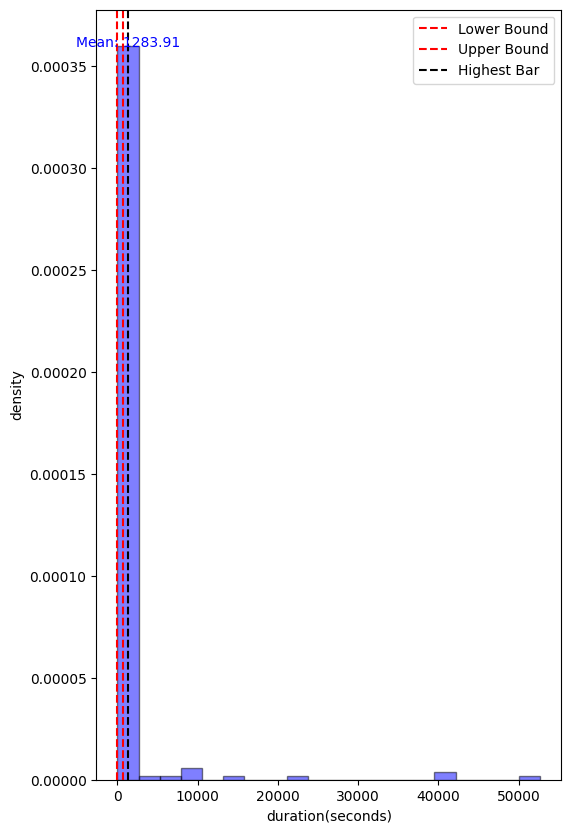

In [89]:
data = df_result['interval']

plt.figure(figsize=(6,10))
# Calculate IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
if lower_bound < 0:
    lower_bound = 0

upper_bound = Q3 + 1.5 * IQR

# Create the histogram with density probability and blue color
bin_counts, bin_edges, _ = plt.hist(data, bins=20, density=True, color='blue', alpha=0.5, edgecolor='black')

# Add IQR boundaries
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

# Find the bin with the highest count
highest_bin_index = np.argmax(bin_counts)
highest_bin_value = bin_edges[highest_bin_index]

# Calculate the mean
mean_value = np.mean(data)

# Add a line at the highest bar
plt.axvline(mean_value, color='black', linestyle='--', label='Highest Bar')

# Display the mean value at the highest bar
plt.text(mean_value, max(bin_counts), f'Mean: {mean_value:.2f}', color='blue', ha='center')

# Set x-axis tick values and labels
# plt.xticks([0, 50, 100, 150, 200])

# Show the legend
plt.legend()

# giving X and Y labels
plt.xlabel("duration(seconds)")
plt.ylabel("density")

# Display the plot
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x22976dde500>,
 'caps': [<matplotlib.lines.Line2D at 0x22976ddc280>,
 'boxes': [<matplotlib.lines.Line2D at 0x22976ddd8a0>],
 'medians': [<matplotlib.lines.Line2D at 0x22976ddd120>],
 'fliers': [<matplotlib.lines.Line2D at 0x22976ddd480>],
 'means': []}

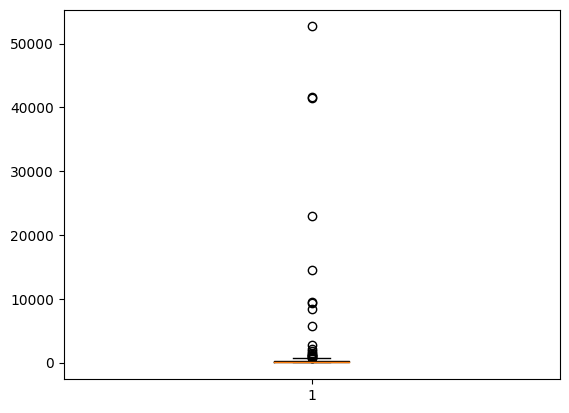

In [90]:
plt.boxplot(df_result['interval'])

In [91]:
Q1 = np.percentile(df_result['interval'], 25)
Q3 = np.percentile(df_result['interval'], 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_result_cleaned = df_result[~((df_result['interval'] < lower_bound) | (df_result['interval'] > upper_bound))]
df_result_cleaned.head()

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,1,2023-10-01 00:20:19,2023-10-01 00:24:11,1376,232.0,1376.0,65.066379,92.213327
1,1,2023-10-01 00:35:30,2023-10-01 00:35:45,2137,15.0,2137.5,61.429271,66.129308
2,2,2023-10-01 01:26:04,2023-10-01 01:26:51,5187,47.0,5187.5,65.239898,80.926057
3,2,2023-10-01 01:40:14,2023-10-01 01:40:39,6026,25.0,6026.5,64.979220,74.534334
4,3,2023-10-01 02:25:06,2023-10-01 02:25:44,8725,38.0,8725.0,64.462776,78.072541


{'whiskers': [<matplotlib.lines.Line2D at 0x22976e2cfa0>,
 'caps': [<matplotlib.lines.Line2D at 0x22976e2e0b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x22976e2efe0>],
 'medians': [<matplotlib.lines.Line2D at 0x22976e2dae0>],
 'fliers': [<matplotlib.lines.Line2D at 0x22976e2c700>],
 'means': []}

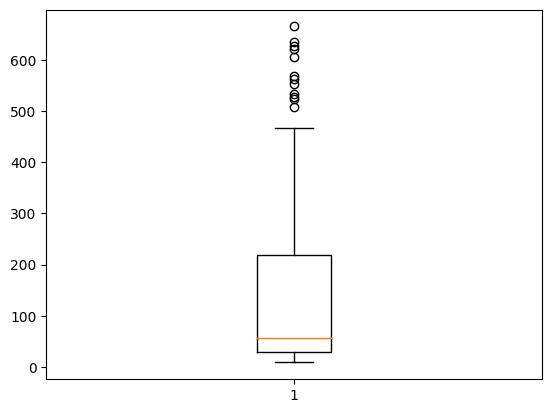

In [92]:
plt.boxplot(df_result_cleaned['interval'])

In [93]:
df_result_cleaned

,hours,start_time,end_time,peak_time,interval,median,Leq,Lae
0,1,2023-10-01 00:20:19,2023-10-01 00:24:11,1376,232.0,1376.0,65.066379,92.213327
1,1,2023-10-01 00:35:30,2023-10-01 00:35:45,2137,15.0,2137.5,61.429271,66.129308
2,2,2023-10-01 01:26:04,2023-10-01 01:26:51,5187,47.0,5187.5,65.239898,80.926057
3,2,2023-10-01 01:40:14,2023-10-01 01:40:39,6026,25.0,6026.5,64.979220,74.534334
4,3,2023-10-01 02:25:06,2023-10-01 02:25:44,8725,38.0,8725.0,64.462776,78.072541
...,...,...,...,...,...,...,...,...
184,102,2023-10-05 05:31:33,2023-10-05 05:32:21,365277,48.0,365277.0,62.170383,78.062735
185,102,2023-10-05 05:36:56,2023-10-05 05:44:09,365795,433.0,365795.0,62.537172,91.822407
186,102,2023-10-05 05:46:49,2023-10-05 05:47:10,366179,21.0,366179.5,61.858585,69.743159
187,102,2023-10-05 05:51:57,2023-10-05 05:52:11,366484,14.0,366484.0,61.429904,65.484555


In [94]:
for i in range(n_data_points//3600):
    data = df_result_cleaned[df_result_cleaned['hours'] == i+1]
    Lae_in_this_hour = np.array(data['Lae'])
    Leq_in_this_hour = np.array(data['Leq'])

    print(f"Hour#{i+1}")

    if(len(Lae_in_this_hour) == 0 and len(Leq_in_this_hour) == 0):
        print("no aircraft.")
    else:
        Leq = SoundAddition(Leq_in_this_hour)
        Lae = SoundAddition(Lae_in_this_hour)
        
        print ("Hour#%d has %d aircraft(s) and sum of Leq of those aircraft(s) is %f and Lae is %f." % ((i+1), len(data), Leq, Lae))

    # aircraft_info.append({'start_time':time_start, 'end_time':time_end, 'aircrafts':len([df_result_cleaned['hours'] == i])})

    print()

Hour#1
Hour#1 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 66.628241 and Lae is 92.224014.

Hour#2
Hour#2 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 68.121814 and Lae is 81.823427.

Hour#3
Hour#3 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 67.626031 and Lae is 80.324565.

Hour#4
no aircraft.

Hour#5
no aircraft.

Hour#6
Hour#6 has 2 aircraft(s) and sum of Leq of those aircraft(s) is 66.438192 and Lae is 79.436959.

Hour#7
no aircraft.

Hour#8
Hour#8 has 4 aircraft(s) and sum of Leq of those aircraft(s) is 81.899726 and Lae is 107.489885.

Hour#9
no aircraft.

Hour#10
Hour#10 has 7 aircraft(s) and sum of Leq of those aircraft(s) is 73.143403 and Lae is 90.755207.

Hour#11
Hour#11 has 1 aircraft(s) and sum of Leq of those aircraft(s) is 62.443315 and Lae is 79.307304.

Hour#12
Hour#12 has 1 aircraft(s) and sum of Leq of those aircraft(s) is 78.760814 and Lae is 112.433772.

Hour#13
Hour#13 has 6 aircraft(s) and sum of Leq of those aircraft(s) is 86.